# Tech Challenge - Fase 3
## Análise Exploratória de Dados e Modelagem de Classificação para Previsão de Atrasos de Voos

Este projeto tem como objetivo analisar dados de voos nos Estados Unidos e construir um modelo de Machine Learning capaz de prever se um voo irá atrasar ou não.

Nesta etapa, serão realizadas:
- integração das bases de dados;
- análise exploratória dos dados (EDA);
- tratamento de valores ausentes;
- criação de um modelo supervisionado de classificação.

Essa abordagem está alinhada com os requisitos obrigatórios do Tech Challenge, que incluem estatísticas descritivas, visualizações com insights, tratamento adequado de valores ausentes e modelagem supervisionada por classificação. 

## 1. Importação das bibliotecas

Nesta seção, são importadas as bibliotecas necessárias para manipulação dos dados, visualização gráfica e construção dos modelos de Machine Learning.

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")

## 2. Carregamento das bases de dados

O projeto utiliza três bases de dados em formato CSV:

- `flights`: contém os registros dos voos;
- `airlines`: contém a identificação das companhias aéreas;
- `airports`: contém informações dos aeroportos.

A base `flights` será utilizada como tabela principal, enquanto as demais serão integradas para enriquecer a análise.

In [2]:
flights = pd.read_csv("flights.csv")
airlines = pd.read_csv("airlines.csv")
airports = pd.read_csv("airports.csv")

C:\Users\pedro_moraes\AppData\Local\Temp\ipykernel_19412\879226408.py:1: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  flights = pd.read_csv("flights.csv")


## 3. Inspeção inicial das bases

Antes da integração, é importante observar a estrutura de cada base, suas colunas, tipos de dados e quantidade de registros.

In [3]:
print("Flights:")
display(flights.head())
print(flights.shape)
print(flights.info())

print("\nAirlines:")
display(airlines.head())
print(airlines.shape)
print(airlines.info())

print("\nAirports:")
display(airports.head())
print(airports.shape)
print(airports.info())

Flights:


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


(5819079, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED          

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


(14, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   IATA_CODE  14 non-null     object
 1   AIRLINE    14 non-null     object
dtypes: object(2)
memory usage: 356.0+ bytes
None

Airports:


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


(322, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   IATA_CODE  322 non-null    object 
 1   AIRPORT    322 non-null    object 
 2   CITY       322 non-null    object 
 3   STATE      322 non-null    object 
 4   COUNTRY    322 non-null    object 
 5   LATITUDE   319 non-null    float64
 6   LONGITUDE  319 non-null    float64
dtypes: float64(2), object(5)
memory usage: 17.7+ KB
None


A partir dessa inspeção inicial, é possível identificar:
- quais colunas estão disponíveis em cada dataset;
- quais variáveis podem ser utilizadas na análise;
- quais colunas funcionarão como chave para o processo de integração.

## 4. Integração das bases de dados

Para enriquecer a base principal de voos, foram realizados merges com as tabelas de companhias aéreas e aeroportos.

Antes disso, foi feita uma padronização simples das colunas-chave, removendo espaços em branco e garantindo consistência no formato dos códigos.

In [4]:
flights["AIRLINE"] = flights["AIRLINE"].astype(str).str.strip()
airlines["IATA_CODE"] = airlines["IATA_CODE"].astype(str).str.strip()

flights["ORIGIN_AIRPORT"] = flights["ORIGIN_AIRPORT"].astype(str).str.strip()
flights["DESTINATION_AIRPORT"] = flights["DESTINATION_AIRPORT"].astype(str).str.strip()
airports["IATA_CODE"] = airports["IATA_CODE"].astype(str).str.strip()

In [5]:
df = flights.merge(
    airlines,
    left_on="AIRLINE",
    right_on="IATA_CODE",
    how="left"
)

df = df.merge(
    airports,
    left_on="ORIGIN_AIRPORT",
    right_on="IATA_CODE",
    how="left",
    suffixes=("", "_ORIGIN")
)

df = df.merge(
    airports,
    left_on="DESTINATION_AIRPORT",
    right_on="IATA_CODE",
    how="left",
    suffixes=("", "_DEST")
)

## 5. Entendimento inicial da base consolidada

Com a base consolidada, é possível analisar sua estrutura geral, os tipos das variáveis e estatísticas descritivas preliminares.

In [6]:
print("Shape:", df.shape)
display(df.head())
display(df.describe())
print(df.info())

Shape: (5819079, 47)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_x,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,COUNTRY,LATITUDE,LONGITUDE,IATA_CODE_DEST,AIRPORT_DEST,CITY_DEST,STATE_DEST,COUNTRY_DEST,LATITUDE_DEST,LONGITUDE_DEST
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,USA,61.17432,-149.99619,SEA,Seattle-Tacoma International Airport,Seattle,WA,USA,47.44898,-122.30931
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,USA,33.94254,-118.40807,PBI,Palm Beach International Airport,West Palm Beach,FL,USA,26.68316,-80.09559
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,USA,37.61900,-122.37484,CLT,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21401,-80.94313
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,USA,33.94254,-118.40807,MIA,Miami International Airport,Miami,FL,USA,25.79325,-80.29056
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,USA,47.44898,-122.30931,ANC,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.17432,-149.99619


,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,LATITUDE,LONGITUDE,LATITUDE_DEST,LONGITUDE_DEST
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.732926e+06,5.732926e+06,5.730032e+06,5.730032e+06,...,5.819079e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,5.328309e+06,5.328309e+06,5.328304e+06,5.328304e+06
mean,2015.0,6.524085e+00,1.570459e+01,3.926941e+00,2.173093e+03,1.329602e+03,1.335204e+03,9.370158e+00,1.607166e+01,1.357171e+03,...,1.544643e-02,1.348057e+01,7.615387e-02,1.896955e+01,2.347284e+01,2.915290e+00,3.663806e+01,-9.549123e+01,3.663795e+01,-9.549102e+01
std,0.0,3.405137e+00,8.783425e+00,1.988845e+00,1.757064e+03,4.837518e+02,4.964233e+02,3.708094e+01,8.895574e+00,4.980094e+02,...,1.233201e-01,2.800368e+01,2.143460e+00,4.816164e+01,4.319702e+01,2.043334e+01,5.999338e+00,1.815637e+01,5.999285e+00,1.815616e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.348345e+01,-1.766460e+02,1.348345e+01,-1.766460e+02
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,7.300000e+02,9.170000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.289595e+01,-1.119778e+02,3.289595e+01,-1.119778e+02
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,1.690000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,...,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00,3.736186e+01,-9.025803e+01,3.736186e+01,-9.025803e+01
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.230000e+03,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,...,0.000000e+00,1.800000e+01,0.000000e+00,1.900000e+01,2.900000e+01,0.000000e+00,4.078839e+01,-8.168786e+01,4.078839e+01,-8.168786e+01
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.855000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,...,1.000000e+00,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03,7.128545e+01,-6.479856e+01,7.128545e+01,-6.479856e+01


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 47 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE_x            object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

Essa etapa permite identificar:
- o volume total de registros;
- a quantidade de variáveis disponíveis;
- a existência de variáveis numéricas e categóricas;
- indícios iniciais de inconsistências ou valores ausentes.

## 6. Análise de valores ausentes

Foi feita uma análise da quantidade e da proporção de valores nulos em cada coluna.

In [7]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
})

display(missing_df[missing_df["missing_count"] > 0])

,missing_count,missing_pct
CANCELLATION_REASON,5729195,98.455357
LATE_AIRCRAFT_DELAY,4755640,81.724960
WEATHER_DELAY,4755640,81.724960
AIRLINE_DELAY,4755640,81.724960
AIR_SYSTEM_DELAY,4755640,81.724960
SECURITY_DELAY,4755640,81.724960
LATITUDE_DEST,490775,8.433895
LONGITUDE_DEST,490775,8.433895
LONGITUDE,490770,8.433809
LATITUDE,490770,8.433809


Os valores ausentes não devem ser tratados todos da mesma forma. Em bases de voos, a ausência de informação pode ocorrer por diferentes motivos operacionais, como cancelamentos, desvios, ou simplesmente porque determinado tipo de atraso não aconteceu.

Assim, o tratamento será feito de maneira contextualizada.

## 7. Tratamento dos valores ausentes e limpeza da base

Nesta etapa, foram aplicadas decisões de limpeza com base no significado das variáveis:

- remoção de voos cancelados;
- preenchimento com zero em colunas nas quais a ausência indica inexistência daquele tipo de atraso;
- remoção de colunas irrelevantes ou excessivamente incompletas;
- manutenção apenas de registros com informação disponível para a variável alvo da classificação.

In [8]:
df = df[df["CANCELLED"] == 0].copy()
print(df.shape)

(5729195, 47)


Como o objetivo desta etapa é prever se o voo atrasará ou não, optou-se por remover voos cancelados, pois eles representam uma situação operacional diferente da lógica de atraso normal.

In [9]:
delay_cols = [
    "AIR_SYSTEM_DELAY",
    "SECURITY_DELAY",
    "AIRLINE_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "WEATHER_DELAY"
]

for col in delay_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

Nas colunas de tipos específicos de atraso, a ausência de valor foi interpretada como inexistência daquele tipo de atraso. Por isso, os valores ausentes foram preenchidos com zero.

A coluna `CANCELLATION_REASON` foi removida, pois se torna irrelevante após a exclusão dos voos cancelados.

In [10]:
if "CANCELLATION_REASON" in df.columns:
    df.drop(columns=["CANCELLATION_REASON"], inplace=True)

### Removendo coluna que não possuem valor para a análise

In [11]:
cols_to_drop_if_exist = [
    "LATITUDE", "LONGITUDE", "LATITUDE_DEST", "LONGITUDE_DEST"
]

existing_cols = [col for col in cols_to_drop_if_exist if col in df.columns]
df.drop(columns=existing_cols, inplace=True)

As colunas geográficas de latitude e longitude foram removidas nesta etapa, pois não são essenciais para a modelagem de classificação proposta e apresentavam valores ausentes residuais.

In [12]:
df = df.dropna(subset=["ARRIVAL_DELAY"]).copy()
print(df.shape)

(5714008, 42)


Como a variável de classificação será construída a partir do atraso na chegada, foram mantidos apenas os registros com valor disponível em `ARRIVAL_DELAY`.

Conferindo a ausência de dados novamente:

In [13]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
})

display(missing_df[missing_df["missing_count"] > 0].head(20))

,missing_count,missing_pct
IATA_CODE_ORIGIN,482878,8.450776
AIRPORT,482878,8.450776
STATE_DEST,482878,8.450776
COUNTRY_DEST,482878,8.450776
CITY_DEST,482878,8.450776
AIRPORT_DEST,482878,8.450776
IATA_CODE_DEST,482878,8.450776
COUNTRY,482878,8.450776
STATE,482878,8.450776
CITY,482878,8.450776


## 8. Criação da variável alvo para classificação

O objetivo da modelagem supervisionada nesta etapa é prever se um voo irá atrasar ou não.

Para isso, foi criada a variável `IS_DELAYED`, definida da seguinte forma:

- `1`: voo com atraso na chegada;
- `0`: voo sem atraso na chegada.

In [14]:
df["IS_DELAYED"] = (df["ARRIVAL_DELAY"] > 0).astype(int)
df["IS_DELAYED"].value_counts()

IS_DELAYED
0    3627112
1    2086896
Name: count, dtype: int64

Essa variável transforma o problema em uma tarefa de classificação binária.

## 9. Estatísticas descritivas

Nesta etapa, são analisadas estatísticas descritivas das principais variáveis numéricas relacionadas ao problema de atraso.

In [15]:
display(df[[
    "ARRIVAL_DELAY",
    "DEPARTURE_DELAY",
    "DISTANCE",
    "SCHEDULED_TIME"
]].describe())

,ARRIVAL_DELAY,DEPARTURE_DELAY,DISTANCE,SCHEDULED_TIME
count,5.714008e+06,5.714008e+06,5.714008e+06,5.714008e+06
mean,4.407057e+00,9.294842e+00,8.244569e+02,1.418940e+02
std,3.927130e+01,3.688972e+01,6.086620e+02,7.531400e+01
min,-8.700000e+01,-8.200000e+01,3.100000e+01,1.800000e+01
25%,-1.300000e+01,-5.000000e+00,3.730000e+02,8.500000e+01
50%,-5.000000e+00,-2.000000e+00,6.500000e+02,1.230000e+02
75%,8.000000e+00,7.000000e+00,1.065000e+03,1.740000e+02
max,1.971000e+03,1.988000e+03,4.983000e+03,7.180000e+02


As estatísticas descritivas ajudam a compreender a distribuição geral dos dados, a presença de valores extremos e o comportamento médio das variáveis mais relevantes para o problema.

## 10. Análise exploratória de dados (EDA)

A análise exploratória tem como objetivo identificar padrões, tendências e possíveis fatores associados aos atrasos dos voos. Para isso, serão utilizadas visualizações que permitam interpretar o comportamento da base sob diferentes perspectivas.

### 10.1 Distribuição do atraso na chegada

O histograma abaixo permite visualizar como os atrasos estão distribuídos na base.

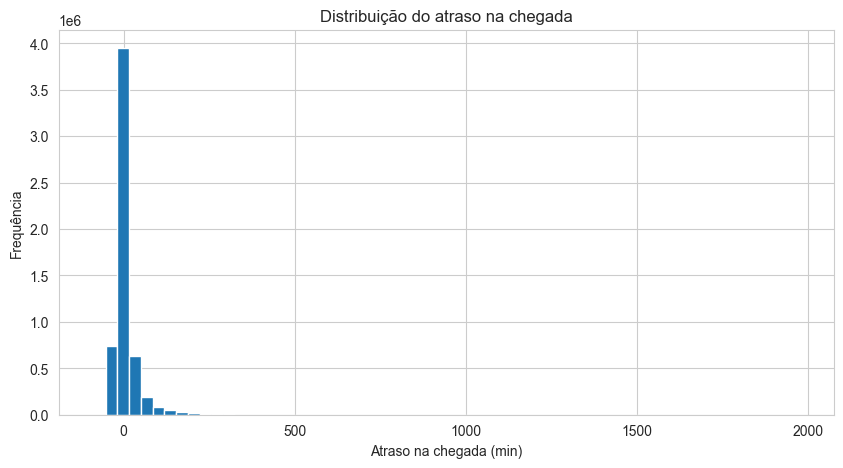

In [16]:
plt.figure(figsize=(10, 5))
plt.hist(df["ARRIVAL_DELAY"], bins=60)
plt.title("Distribuição do atraso na chegada")
plt.xlabel("Atraso na chegada (min)")
plt.ylabel("Frequência")
plt.show()

Esse gráfico permite observar a presença de concentração de voos próximos do horário previsto, além de possíveis outliers com atrasos muito elevados.

### 10.2 Boxplot do atraso na chegada

O boxplot permite identificar a dispersão da variável e a presença de valores extremos.

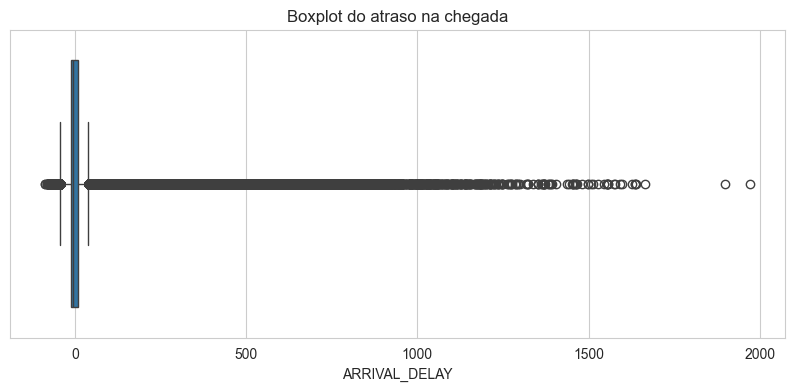

In [17]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["ARRIVAL_DELAY"])
plt.title("Boxplot do atraso na chegada")
plt.show()

A presença de outliers é esperada em variáveis de atraso, já que alguns voos podem sofrer atrasos muito superiores à média.

### 10.3 Proporção de voos com atraso

Nesta visualização, observa-se a distribuição da variável alvo criada para a classificação.

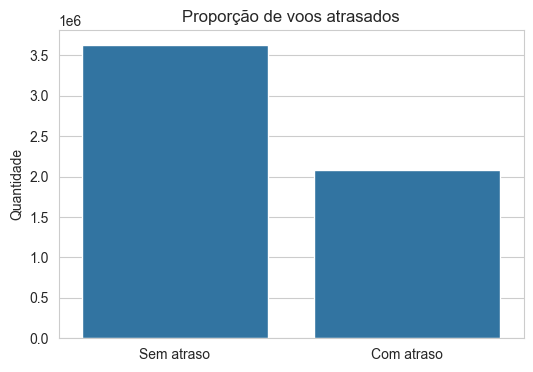

IS_DELAYED
0    0.634775
1    0.365225
Name: proportion, dtype: float64


In [18]:
delay_counts = df["IS_DELAYED"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
sns.barplot(x=["Sem atraso", "Com atraso"], y=delay_counts.values)
plt.title("Proporção de voos atrasados")
plt.ylabel("Quantidade")
plt.show()

print(df["IS_DELAYED"].value_counts(normalize=True))

A distribuição entre voos atrasados e não atrasados indica que o problema apresenta um certo nível de desbalanceamento.

Essa característica é importante, pois pode influenciar diretamente o desempenho dos modelos de classificação, especialmente em métricas como precisão e recall.


### 10.4 Atraso médio por companhia aérea

Nesta etapa, avalia-se como o atraso médio varia entre as companhias aéreas.

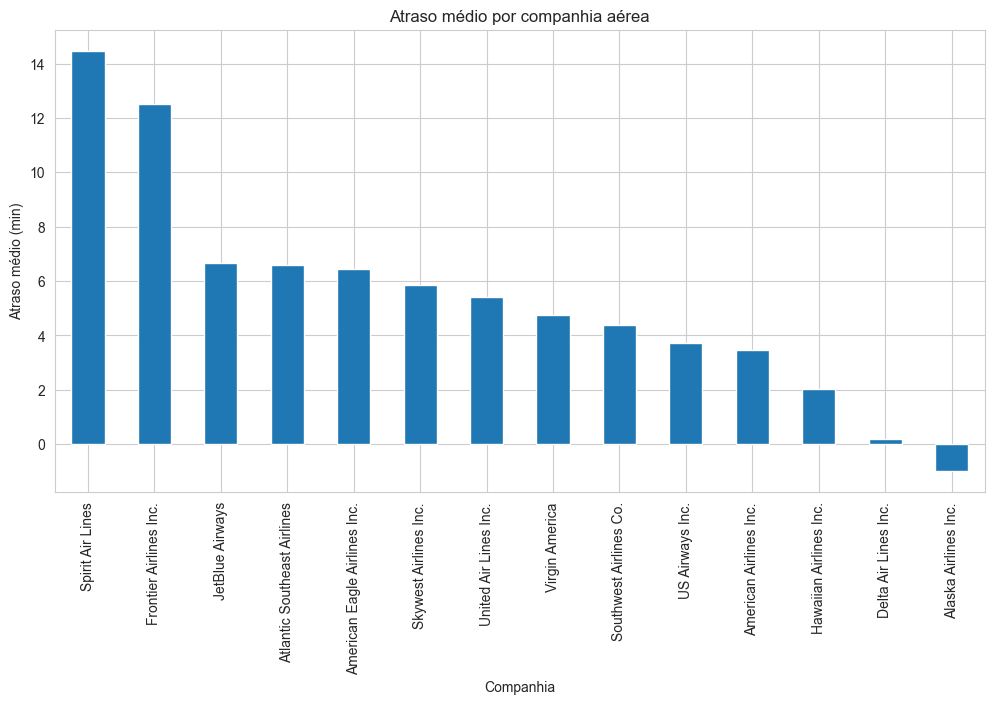

In [19]:
if "AIRLINE_y" in df.columns:
    df.rename(columns={"AIRLINE_y": "AIRLINE_NAME"}, inplace=True)
elif "AIRLINE" in df.columns:
    df.rename(columns={"AIRLINE": "AIRLINE_NAME"}, inplace=True)

airline_delay = (
    df.groupby("AIRLINE_NAME")["ARRIVAL_DELAY"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
airline_delay.plot(kind="bar")
plt.title("Atraso médio por companhia aérea")
plt.xlabel("Companhia")
plt.ylabel("Atraso médio (min)")
plt.show()

Observa-se que algumas companhias apresentam atraso médio superior às demais, indicando diferenças no desempenho operacional entre elas.

Essa variação sugere que fatores internos, como gestão de rotas e eficiência logística, podem impactar diretamente a ocorrência de atrasos.

Dessa forma, a companhia aérea se mostra uma variável relevante para a modelagem preditiva.

### 10.5 Taxa de voos atrasados por companhia aérea

Além do atraso médio, também é relevante avaliar a proporção de voos atrasados por companhia.

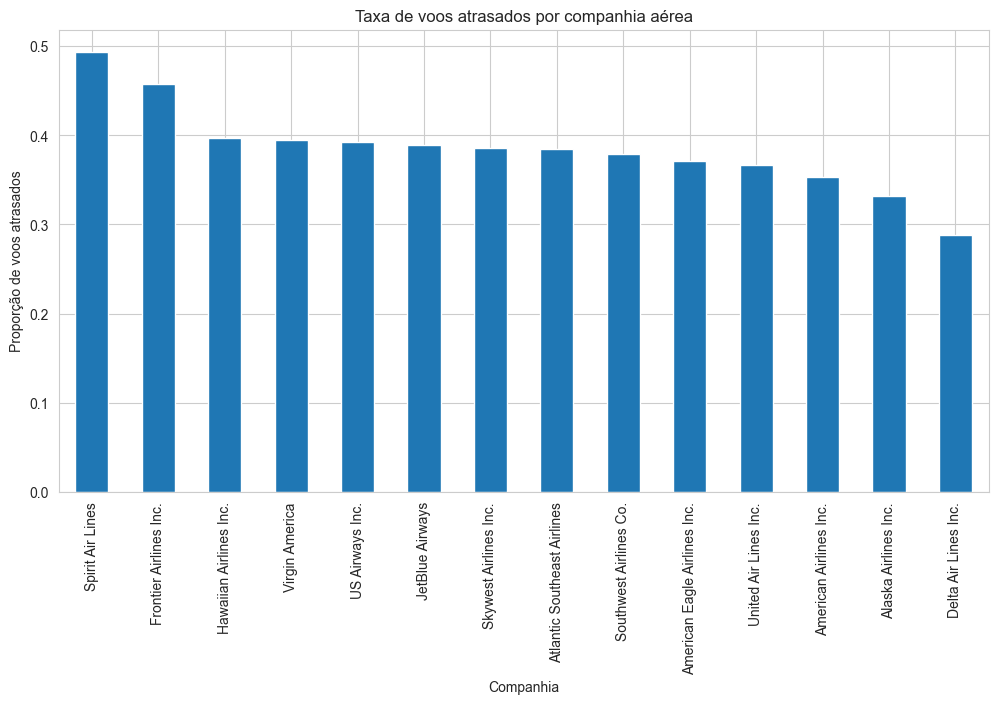

In [20]:
airline_rate = (
    df.groupby("AIRLINE_NAME")["IS_DELAYED"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
airline_rate.plot(kind="bar")
plt.title("Taxa de voos atrasados por companhia aérea")
plt.xlabel("Companhia")
plt.ylabel("Proporção de voos atrasados")
plt.show()

Além do atraso médio, a proporção de voos atrasados por companhia reforça a existência de diferenças consistentes entre as empresas.

Companhias com maior taxa de atraso podem indicar maior exposição a rotas críticas ou menor eficiência operacional.

### 10.6 Cidades de origem com maior atraso médio

A análise a seguir busca identificar aeroportos ou cidades de origem mais críticos em termos de atraso médio.

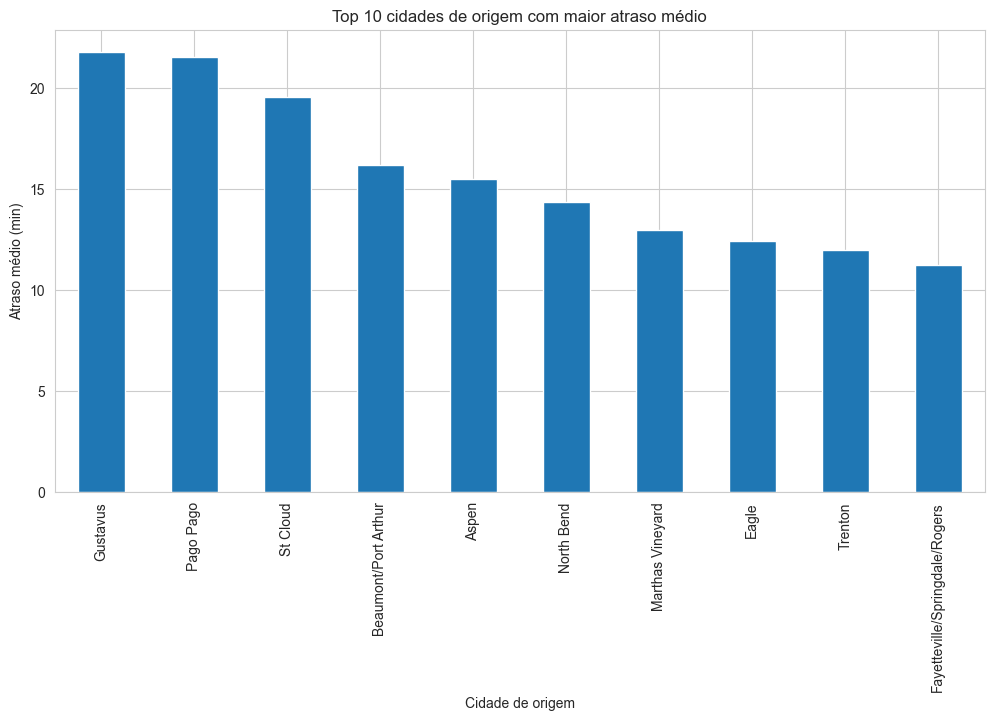

In [21]:
top_origin = (
    df.groupby("CITY")["ARRIVAL_DELAY"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
top_origin.plot(kind="bar")
plt.title("Top 10 cidades de origem com maior atraso médio")
plt.xlabel("Cidade de origem")
plt.ylabel("Atraso médio (min)")
plt.show()

### 10.7 Cidades de destino com maior atraso médio

Também é importante investigar se determinados destinos concentram maiores atrasos.

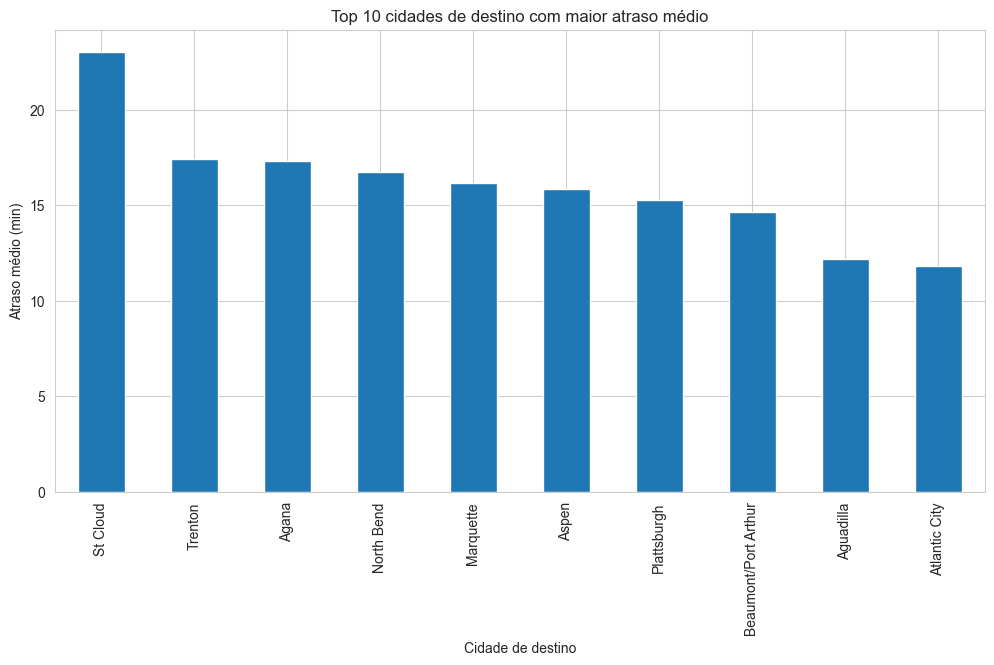

In [22]:
top_dest = (
    df.groupby("CITY_DEST")["ARRIVAL_DELAY"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
top_dest.plot(kind="bar")
plt.title("Top 10 cidades de destino com maior atraso médio")
plt.xlabel("Cidade de destino")
plt.ylabel("Atraso médio (min)")
plt.show()

### 10.8 Atraso médio por dia da semana

A análise temporal permite investigar se os atrasos se concentram em determinados dias.

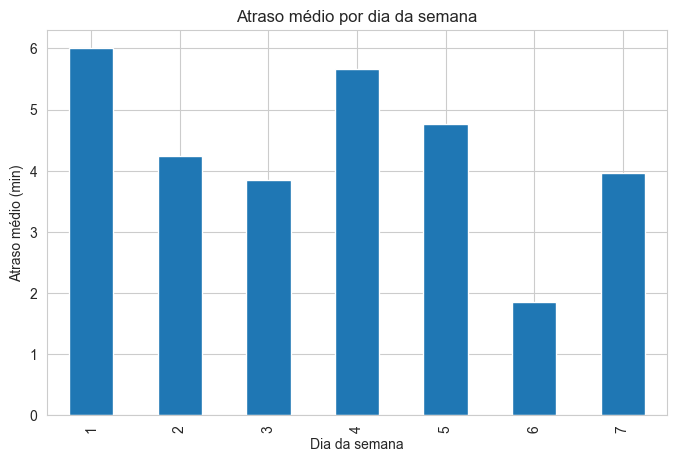

In [23]:
dow_delay = df.groupby("DAY_OF_WEEK")["ARRIVAL_DELAY"].mean()

plt.figure(figsize=(8, 5))
dow_delay.plot(kind="bar")
plt.title("Atraso médio por dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Atraso médio (min)")
plt.show()

### 10.9 Atraso médio por horário programado de partida

Nesta análise, foi criada uma variável de hora a partir do horário programado de partida, permitindo identificar possíveis horários críticos.

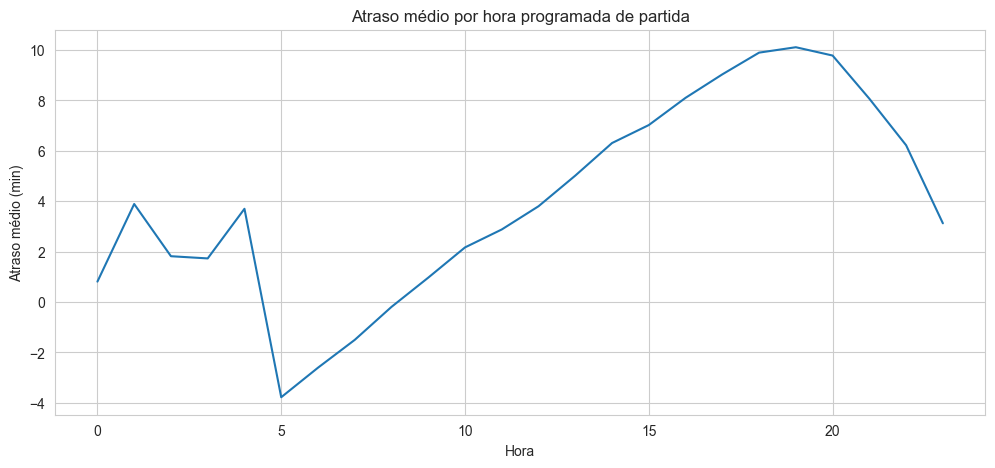

In [24]:
df["DEP_HOUR"] = df["SCHEDULED_DEPARTURE"] // 100

hour_delay = df.groupby("DEP_HOUR")["ARRIVAL_DELAY"].mean()

plt.figure(figsize=(12, 5))
hour_delay.plot()
plt.title("Atraso médio por hora programada de partida")
plt.xlabel("Hora")
plt.ylabel("Atraso médio (min)")
plt.show()

Observa-se que os atrasos tendem a aumentar em determinados períodos do dia, especialmente ao longo do avanço das horas.

Esse padrão pode ser explicado pelo acúmulo de atrasos operacionais ao longo do dia, onde pequenos atrasos iniciais impactam voos subsequentes.

Isso indica que o horário programado do voo é uma variável altamente relevante para o modelo.

### 10.10 Correlação entre variáveis numéricas

O mapa de calor abaixo permite observar relações lineares entre variáveis numéricas da base.

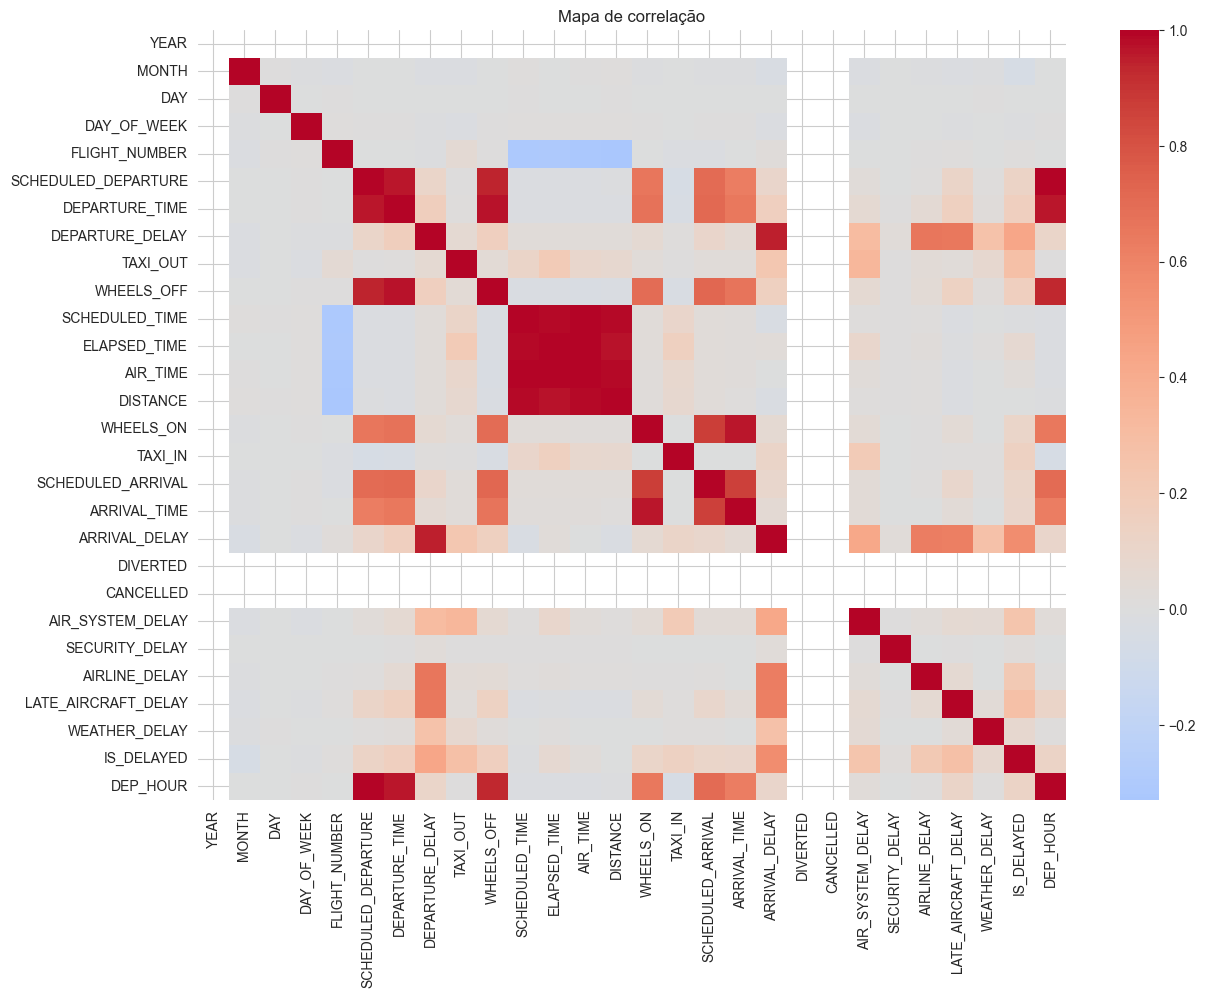

In [25]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0)
plt.title("Mapa de correlação")
plt.show()

A correlação não implica causalidade, mas ajuda a identificar variáveis potencialmente relevantes para a modelagem.

### 10.11 Tipos de atraso mais representativos

Nesta visualização, analisa-se a magnitude média dos diferentes tipos de atraso registrados na base.

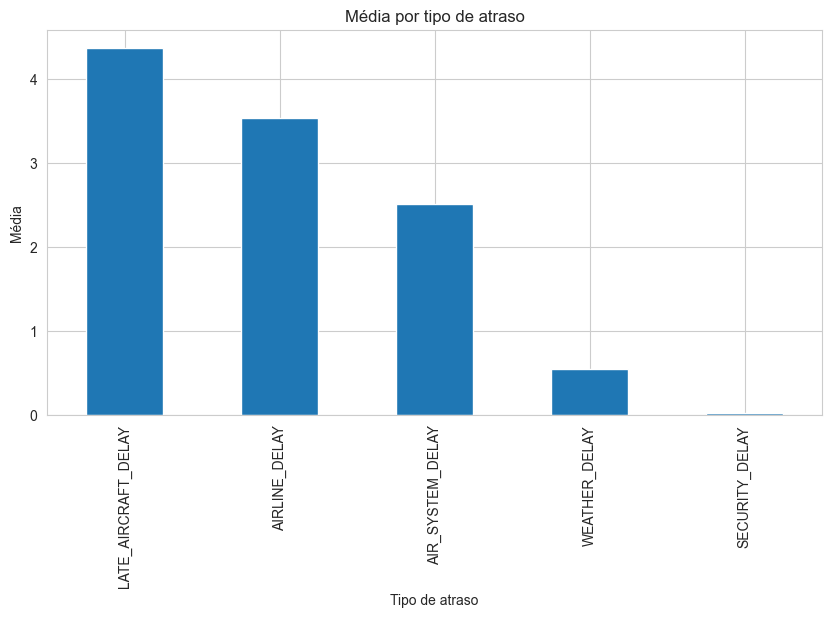

In [26]:
delay_means = df[delay_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
delay_means.plot(kind="bar")
plt.title("Média por tipo de atraso")
plt.xlabel("Tipo de atraso")
plt.ylabel("Média")
plt.show()

A análise dos diferentes tipos de atraso mostra quais fatores têm maior impacto no atraso total dos voos.

Observa-se que determinados tipos, como atraso da companhia ou atraso de aeronave, possuem maior contribuição média.

Isso fornece uma visão mais operacional do problema, indicando possíveis pontos de melhoria nos processos envolvidos.

## 11. Principais insights da análise exploratória

Com base nas análises realizadas, é possível resumir alguns pontos relevantes observados no comportamento dos atrasos.

In [27]:
print("Proporção de voos atrasados:")
print(df["IS_DELAYED"].mean())

print("\nTop 5 companhias com maior atraso médio:")
print(df.groupby("AIRLINE_NAME")["ARRIVAL_DELAY"].mean().sort_values(ascending=False).head())

print("\nTop 5 cidades de origem com maior atraso médio:")
print(df.groupby("CITY")["ARRIVAL_DELAY"].mean().sort_values(ascending=False).head())

print("\nTop 5 horários com maior atraso médio:")
print(df.groupby("DEP_HOUR")["ARRIVAL_DELAY"].mean().sort_values(ascending=False).head())

Proporção de voos atrasados:
0.36522454991312575

Top 5 companhias com maior atraso médio:
AIRLINE_NAME
Spirit Air Lines                14.471800
Frontier Airlines Inc.          12.504706
JetBlue Airways                  6.677861
Atlantic Southeast Airlines      6.585379
American Eagle Airlines Inc.     6.457873
Name: ARRIVAL_DELAY, dtype: float64

Top 5 cidades de origem com maior atraso médio:
CITY
Gustavus                21.763158
Pago Pago               21.500000
St Cloud                19.558442
Beaumont/Port Arthur    16.154696
Aspen                   15.492492
Name: ARRIVAL_DELAY, dtype: float64

Top 5 horários com maior atraso médio:
DEP_HOUR
19    10.106979
18     9.892409
20     9.776880
17     9.030490
16     8.099574
Name: ARRIVAL_DELAY, dtype: float64


De forma geral, a análise exploratória permite identificar que os atrasos não se distribuem uniformemente entre companhias, aeroportos e horários. Esses padrões reforçam a relevância de construir um modelo supervisionado capaz de capturar essas relações e prever a ocorrência de atrasos.

## 12. Seleção de variáveis para classificação

Para a etapa de modelagem, foram selecionadas variáveis que podem estar disponíveis antes da realização do voo, evitando vazamento de informação.

Foram priorizadas variáveis relacionadas a:
- data do voo;
- companhia aérea;
- aeroporto de origem e destino;
- horário programado;
- duração prevista;
- distância.

In [28]:
features = [
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "AIRLINE_NAME",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "SCHEDULED_DEPARTURE",
    "SCHEDULED_TIME",
    "DISTANCE"
]

target = "IS_DELAYED"

model_df = df[features + [target]].copy()
display(model_df.head())

,MONTH,DAY,DAY_OF_WEEK,AIRLINE_NAME,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,SCHEDULED_TIME,DISTANCE,IS_DELAYED
0,1,1,4,Alaska Airlines Inc.,ANC,SEA,5,205.0,1448,0
1,1,1,4,American Airlines Inc.,LAX,PBI,10,280.0,2330,0
2,1,1,4,US Airways Inc.,SFO,CLT,20,286.0,2296,1
3,1,1,4,American Airlines Inc.,LAX,MIA,20,285.0,2342,0
4,1,1,4,Alaska Airlines Inc.,SEA,ANC,25,235.0,1448,0


## 13. Separação entre treino e teste

Para avaliar corretamente os modelos, a base foi dividida em conjunto de treino e conjunto de teste, preservando a proporção entre voos atrasados e não atrasados.

In [29]:
X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(4571206, 9) (1142802, 9)


## 14. Pré-processamento dos dados

Como a base possui variáveis numéricas e categóricas, foi criado um pipeline de pré-processamento com:

- imputação de valores ausentes;
- padronização das variáveis numéricas;
- codificação one-hot para variáveis categóricas.

In [30]:
categorical_features = [
    "AIRLINE_NAME",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT"
]

numeric_features = [
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "SCHEDULED_DEPARTURE",
    "SCHEDULED_TIME",
    "DISTANCE"
]

In [31]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## Transição da Análise Exploratória para Modelagem

A análise exploratória permitiu identificar que fatores como companhia aérea, horário do voo, distância e aeroporto de origem possuem influência relevante na ocorrência de atrasos.

Com base nesses insights, foram selecionadas variáveis que representam essas características para a construção do modelo de classificação.

Dessa forma, a modelagem supervisionada foi construída de forma orientada pelos padrões identificados nos dados, aumentando a coerência entre análise e predição.

## 15. Modelo 1 - Regressão Logística

A Regressão Logística foi utilizada como modelo baseline para a tarefa de classificação. Trata-se de um algoritmo amplamente utilizado em problemas binários, com boa interpretabilidade.

In [32]:
logreg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

logreg_model.fit(X_train, y_train)
y_pred_log = logreg_model.predict(X_test)

Avaliando o 1º modelo:

In [33]:
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Logistic Regression
Accuracy: 0.6403471467498307
Precision: 0.5310958516072946
Recall: 0.13027009025370226
F1-score: 0.2092212499711403

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.93      0.77    725423
           1       0.53      0.13      0.21    417379

    accuracy                           0.64   1142802
   macro avg       0.59      0.53      0.49   1142802
weighted avg       0.61      0.64      0.56   1142802



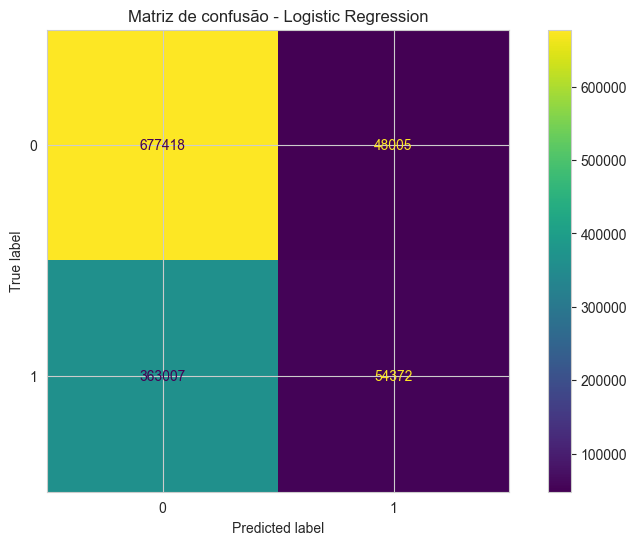

In [34]:
cm_log = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp.plot()
plt.title("Matriz de confusão - Logistic Regression")
plt.show()

A matriz de confusão permite observar como o modelo distribui seus acertos e erros entre as classes.

## 17. Modelo 2 - Árvore de Decisão

Além do modelo baseline de Regressão Logística, foi utilizado um modelo de Árvore de Decisão para a tarefa de classificação.

A Árvore de Decisão é um algoritmo supervisionado não linear que segmenta os dados em diferentes regiões com base em regras de decisão, permitindo capturar relações mais complexas entre as variáveis explicativas e a variável alvo.

Esse tipo de modelo é particularmente útil em cenários onde há interações entre variáveis que não podem ser bem representadas por modelos lineares, como a Regressão Logística.

Inicialmente, foi considerada a utilização de um modelo Random Forest. No entanto, devido ao elevado custo computacional causado pela alta cardinalidade das variáveis categóricas (especialmente aeroportos após codificação one-hot), optou-se por utilizar uma Árvore de Decisão.

Essa escolha permitiu manter a capacidade de modelagem não linear, reduzindo significativamente o tempo de processamento e tornando a execução mais viável no ambiente do projeto.

Para evitar overfitting, foram aplicadas restrições como profundidade máxima da árvore e limites mínimos de amostras por divisão, garantindo melhor generalização do modelo.

In [35]:
tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42
    ))
])

tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

Avaliando o 2º modelo:

In [36]:
print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("F1-score:", f1_score(y_test, y_pred_tree))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_tree))

Decision Tree
Accuracy: 0.653509531834911
Precision: 0.6003524922892312
Recall: 0.15343129386001692
F1-score: 0.2444012762189723

Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.94      0.78    725423
           1       0.60      0.15      0.24    417379

    accuracy                           0.65   1142802
   macro avg       0.63      0.55      0.51   1142802
weighted avg       0.64      0.65      0.58   1142802



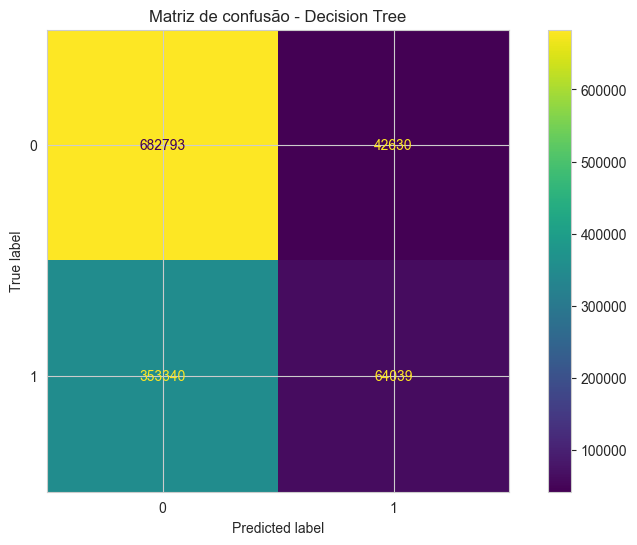

In [37]:
cm_tree = confusion_matrix(y_test, y_pred_tree)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree)
disp.plot()
plt.title("Matriz de confusão - Decision Tree")
plt.show()

## 17.1 Importância das variáveis

Para complementar a avaliação da Árvore de Decisão, foi analisada a importância relativa das variáveis utilizadas no modelo.

Essa análise permite identificar quais atributos tiveram maior influência na previsão de atrasos, contribuindo para a interpretação do comportamento do modelo.

In [38]:
ohe = preprocessor.named_transformers_['cat']['onehot']
cat_features = ohe.get_feature_names_out(categorical_features)

all_features = numeric_features + list(cat_features)

importances = tree_model.named_steps['classifier'].feature_importances_

feat_imp = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feat_imp.head(10)

,Feature,Importance
3,SCHEDULED_DEPARTURE,0.298525
0,MONTH,0.188390
1,DAY,0.179731
10,AIRLINE_NAME_Delta Air Lines Inc.,0.084417
2,DAY_OF_WEEK,0.060871
15,AIRLINE_NAME_Southwest Airlines Co.,0.048826
16,AIRLINE_NAME_Spirit Air Lines,0.018670
8,AIRLINE_NAME_American Eagle Airlines Inc.,0.012241
4,SCHEDULED_TIME,0.011253
13,AIRLINE_NAME_JetBlue Airways,0.009216


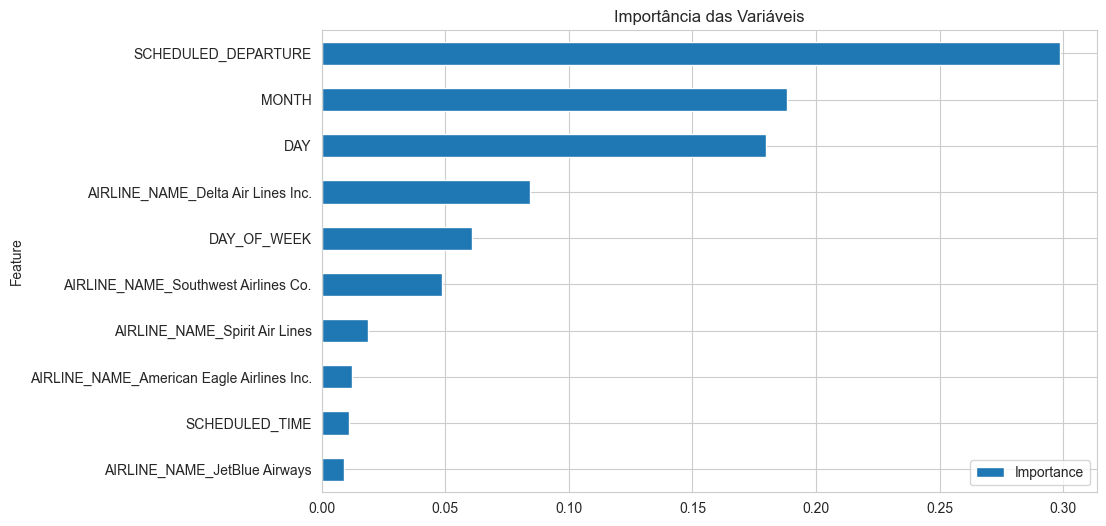

In [39]:
feat_imp.head(10).plot(kind='barh', x='Feature', y='Importance')
plt.title("Importância das Variáveis")
plt.gca().invert_yaxis()
plt.show()

As variáveis mais relevantes para o modelo estão relacionadas principalmente ao horário do voo, distância e companhia aérea.

Esse resultado está alinhado com os padrões observados na análise exploratória, indicando consistência entre os dados e o comportamento do modelo.

## 18. Comparação dos modelos

Para avaliar o desempenho dos modelos de classificação, foram utilizadas métricas como acurácia, precisão, recall e F1-score.

A Regressão Logística foi utilizada como modelo baseline, oferecendo uma abordagem linear e de fácil interpretação. Já a Árvore de Decisão permitiu capturar relações mais complexas entre as variáveis, explorando interações não lineares presentes nos dados.

A comparação entre os modelos permite analisar não apenas a taxa geral de acerto, mas também o equilíbrio entre precisão e recall, especialmente relevante em problemas de classificação onde erros podem ter impactos diferentes.

De forma geral, observa-se que:

- A Regressão Logística tende a apresentar desempenho mais estável e interpretável;
- A Árvore de Decisão pode capturar padrões mais complexos, porém pode ser mais sensível a overfitting;
- O F1-score é utilizado como métrica principal para comparação, pois equilibra precisão e recall.

Essa análise permite selecionar o modelo mais adequado para o problema, considerando tanto desempenho quanto viabilidade de aplicação.

In [40]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_tree)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_tree)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_tree)
    ]
})

display(results.sort_values(by="F1-score", ascending=False))

,Model,Accuracy,Precision,Recall,F1-score
1,Decision Tree,0.653510,0.600352,0.153431,0.244401
0,Logistic Regression,0.640347,0.531096,0.130270,0.209221


In [41]:
best_model = results.sort_values(by="F1-score", ascending=False).iloc[0]["Model"]
print(f"Melhor modelo com base em F1-score: {best_model}")

Melhor modelo com base em F1-score: Decision Tree


Com base no F1-score, a Árvore de Decisão apresentou o melhor desempenho entre os modelos avaliados, indicando maior capacidade de capturar padrões relevantes para a previsão de atrasos.

## 19. Conclusão da etapa de classificação

Os modelos de classificação mostraram que é possível prever a ocorrência de atrasos com base em características disponíveis antes do voo.

A comparação entre Regressão Logística e Árvore de Decisão indicou diferenças importantes entre interpretabilidade e capacidade de capturar relações não lineares, servindo como base para a análise comparativa do projeto.

## 20. Modelagem não supervisionada

Além da modelagem supervisionada, foi aplicada uma abordagem de aprendizado não supervisionado com o objetivo de identificar padrões ocultos nos dados, sem o uso de uma variável alvo.

Neste contexto, foi utilizada a técnica de clusterização para agrupar voos com características semelhantes, permitindo identificar diferentes perfis operacionais relacionados a atrasos.

## 21. Preparação dos dados para clusterização

Para a clusterização, foram selecionadas variáveis numéricas relevantes relacionadas ao comportamento dos voos e atrasos.

As variáveis categóricas foram evitadas nesta etapa para simplificar a análise e melhorar a performance do modelo.

In [42]:
cluster_features = [
    "ARRIVAL_DELAY",
    "DEPARTURE_DELAY",
    "DISTANCE",
    "SCHEDULED_TIME",
    "TAXI_OUT"
]

cluster_df = df[cluster_features].dropna().copy()
cluster_df.head()

,ARRIVAL_DELAY,DEPARTURE_DELAY,DISTANCE,SCHEDULED_TIME,TAXI_OUT
0,-22.0,-11.0,1448,205.0,21.0
1,-9.0,-8.0,2330,280.0,12.0
2,5.0,-2.0,2296,286.0,16.0
3,-9.0,-5.0,2342,285.0,15.0
4,-21.0,-1.0,1448,235.0,11.0


## 22. Padronização dos dados

Como o algoritmo K-Means é sensível à escala das variáveis, foi aplicada a padronização para garantir que todas as variáveis contribuam igualmente para a formação dos clusters.

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_df)

## 23. Determinação do número ideal de clusters

O método do cotovelo (Elbow Method) foi utilizado para identificar o número ideal de clusters, analisando a soma das distâncias intra-cluster.

In [44]:
from sklearn.cluster import KMeans

inertia = []

k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_scaled)
    inertia.append(kmeans.inertia_)

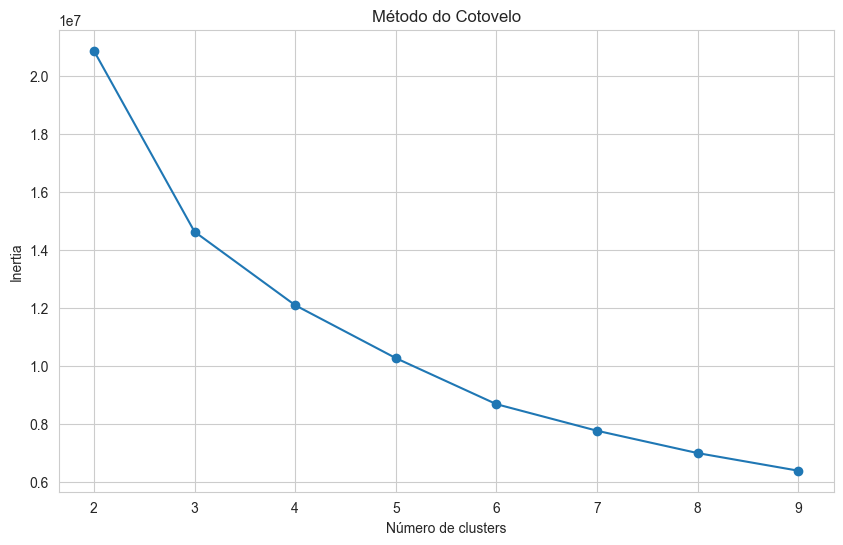

In [45]:
plt.plot(k_range, inertia, marker='o')
plt.title("Método do Cotovelo")
plt.xlabel("Número de clusters")
plt.ylabel("Inertia")
plt.show()

## 24. Aplicação do algoritmo K-Means

Com base na análise anterior, foi aplicado o algoritmo K-Means para segmentar os dados em grupos distintos.

In [46]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(cluster_scaled)

cluster_df["CLUSTER"] = clusters
cluster_df.head()

,ARRIVAL_DELAY,DEPARTURE_DELAY,DISTANCE,SCHEDULED_TIME,TAXI_OUT,CLUSTER
0,-22.0,-11.0,1448,205.0,21.0,0
1,-9.0,-8.0,2330,280.0,12.0,0
2,5.0,-2.0,2296,286.0,16.0,0
3,-9.0,-5.0,2342,285.0,15.0,0
4,-21.0,-1.0,1448,235.0,11.0,0


## 25. Visualização dos clusters

Para facilitar a interpretação, foi utilizada a técnica de redução de dimensionalidade PCA, projetando os dados em duas dimensões.

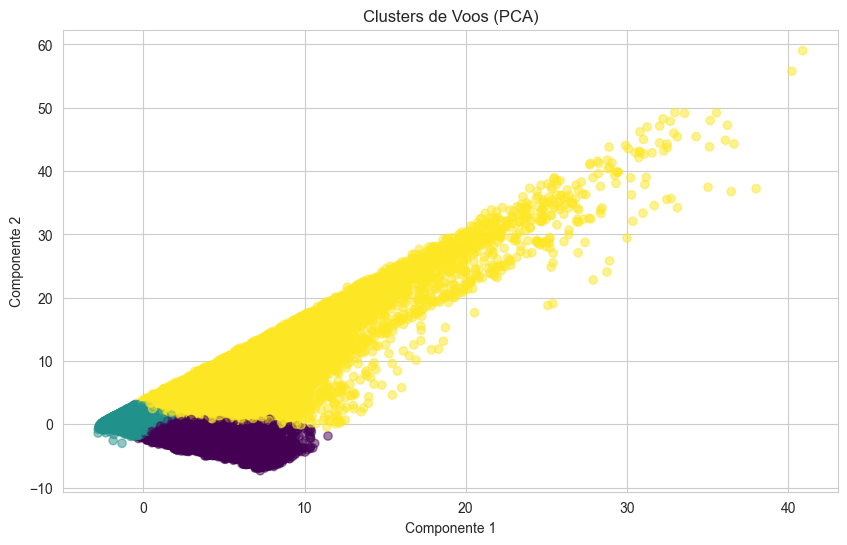

In [ ]:
pca = PCA(n_components=2)
cluster_pca = pca.fit_transform(cluster_scaled)

plt.scatter(cluster_pca[:, 0], cluster_pca[:, 1], c=clusters, cmap='viridis', alpha=0.5)
plt.title("Clusters de Voos (PCA)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()

A visualização dos clusters foi realizada utilizando PCA, que reduz a dimensionalidade dos dados para duas componentes principais.

Cada ponto representa um voo, enquanto as cores indicam os clusters identificados pelo algoritmo K-Means.

Observa-se que os clusters apresentam separação razoável no espaço projetado, indicando que o algoritmo conseguiu identificar padrões distintos nos dados.

O Cluster com maior dispersão apresenta maior variabilidade, possivelmente associado a voos com maior atraso e maior complexidade operacional.

Já os clusters mais concentrados indicam voos com comportamento mais homogêneo, possivelmente com menor nível de atraso.

Apesar da redução de dimensionalidade simplificar a visualização, parte da informação original é perdida, sendo necessário complementar a análise com estatísticas descritivas dos clusters.

## 26. Análise dos clusters

Para interpretar os clusters, foram analisadas as médias das variáveis em cada grupo.

In [48]:
cluster_summary = cluster_df.groupby("CLUSTER").mean()
display(cluster_summary)

,ARRIVAL_DELAY,DEPARTURE_DELAY,DISTANCE,SCHEDULED_TIME,TAXI_OUT
CLUSTER,,,,,
0,-2.994405,5.049525,1825.361159,264.929657,17.685099
1,-1.602011,2.846914,573.791251,110.990336,15.355171
2,139.172288,137.907759,779.613448,137.932044,21.202844


## 27. Interpretação dos resultados

A análise dos clusters permite identificar diferentes perfis de voos:

- Cluster 0 (Verde): voos com baixo atraso e operação mais eficiente
- Cluster 1 (Roxo): voos com atraso moderado
- Cluster 2 (Amarelo): voos com alto atraso e maior tempo de operação

Esses agrupamentos indicam que os dados possuem padrões distintos de comportamento, sugerindo que fatores operacionais influenciam diretamente a ocorrência e magnitude dos atrasos.

A clusterização contribui para uma melhor compreensão dos perfis de voo, podendo ser utilizada para segmentação e tomada de decisão.

## Conclusão

O projeto demonstrou que os atrasos de voos não ocorrem de forma aleatória, estando associados a fatores como companhia aérea, horário e características operacionais.

A análise exploratória permitiu identificar padrões relevantes, enquanto a modelagem supervisionada mostrou que é possível prever a ocorrência de atrasos com base em dados históricos.

Entre os modelos avaliados, a Árvore de Decisão apresentou melhor capacidade de capturar relações não lineares, enquanto a Regressão Logística forneceu uma abordagem mais simples e interpretável.

Além disso, a clusterização revelou diferentes perfis de voos, evidenciando a existência de grupos com comportamentos distintos em relação aos atrasos.

### Limitações

- ausência de variáveis externas (ex: clima, tráfego aéreo)
- simplificação do problema
- possível desbalanceamento dos dados

### Próximos passos

- testar modelos mais avançados (ex: Gradient Boosting)
- criar novas variáveis (feature engineering)
- incorporar dados externos
- melhorar balanceamento de classes